In [16]:
# Importing all required Libraries
# ======================
# 1. Basic Libraries
# ======================
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# =======================
# 2. Preprocessing
# =======================
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

# ======================
# 3. Model Selection
# ======================
# Linear Regression (baseline)
from sklearn.linear_model import LinearRegression
# RandomForestRegressor (intermediate)
from sklearn.ensemble import RandomForestRegressor
# XGBRegressor (advance) but we're not going to use it
#from xgboost import XGBRegressor

# ======================
# 4. Evaluation Metrices
# ======================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 5. Model Validation
# =========================


In [2]:
# Loading the dataset
df = pd.read_csv('train.csv')

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df.shape

(1460, 81)

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
#Checking that how many nan values a column has
df.isnull().sum()[df.isnull().sum()>0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [8]:
#checking again that how many Nan values a column include now

df.isnull().sum()[df.isnull().sum()>0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [9]:



# How Percent % a column has nan values
missing_ratio = df.isnull().mean() * 100
missing_ratio.sort_values(ascending=False)

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

In [10]:
# We are dropping those columns which has more than 50% nan values

df = df.drop(columns=missing_ratio[missing_ratio>50].index)
df = df.drop('Id', axis=1)

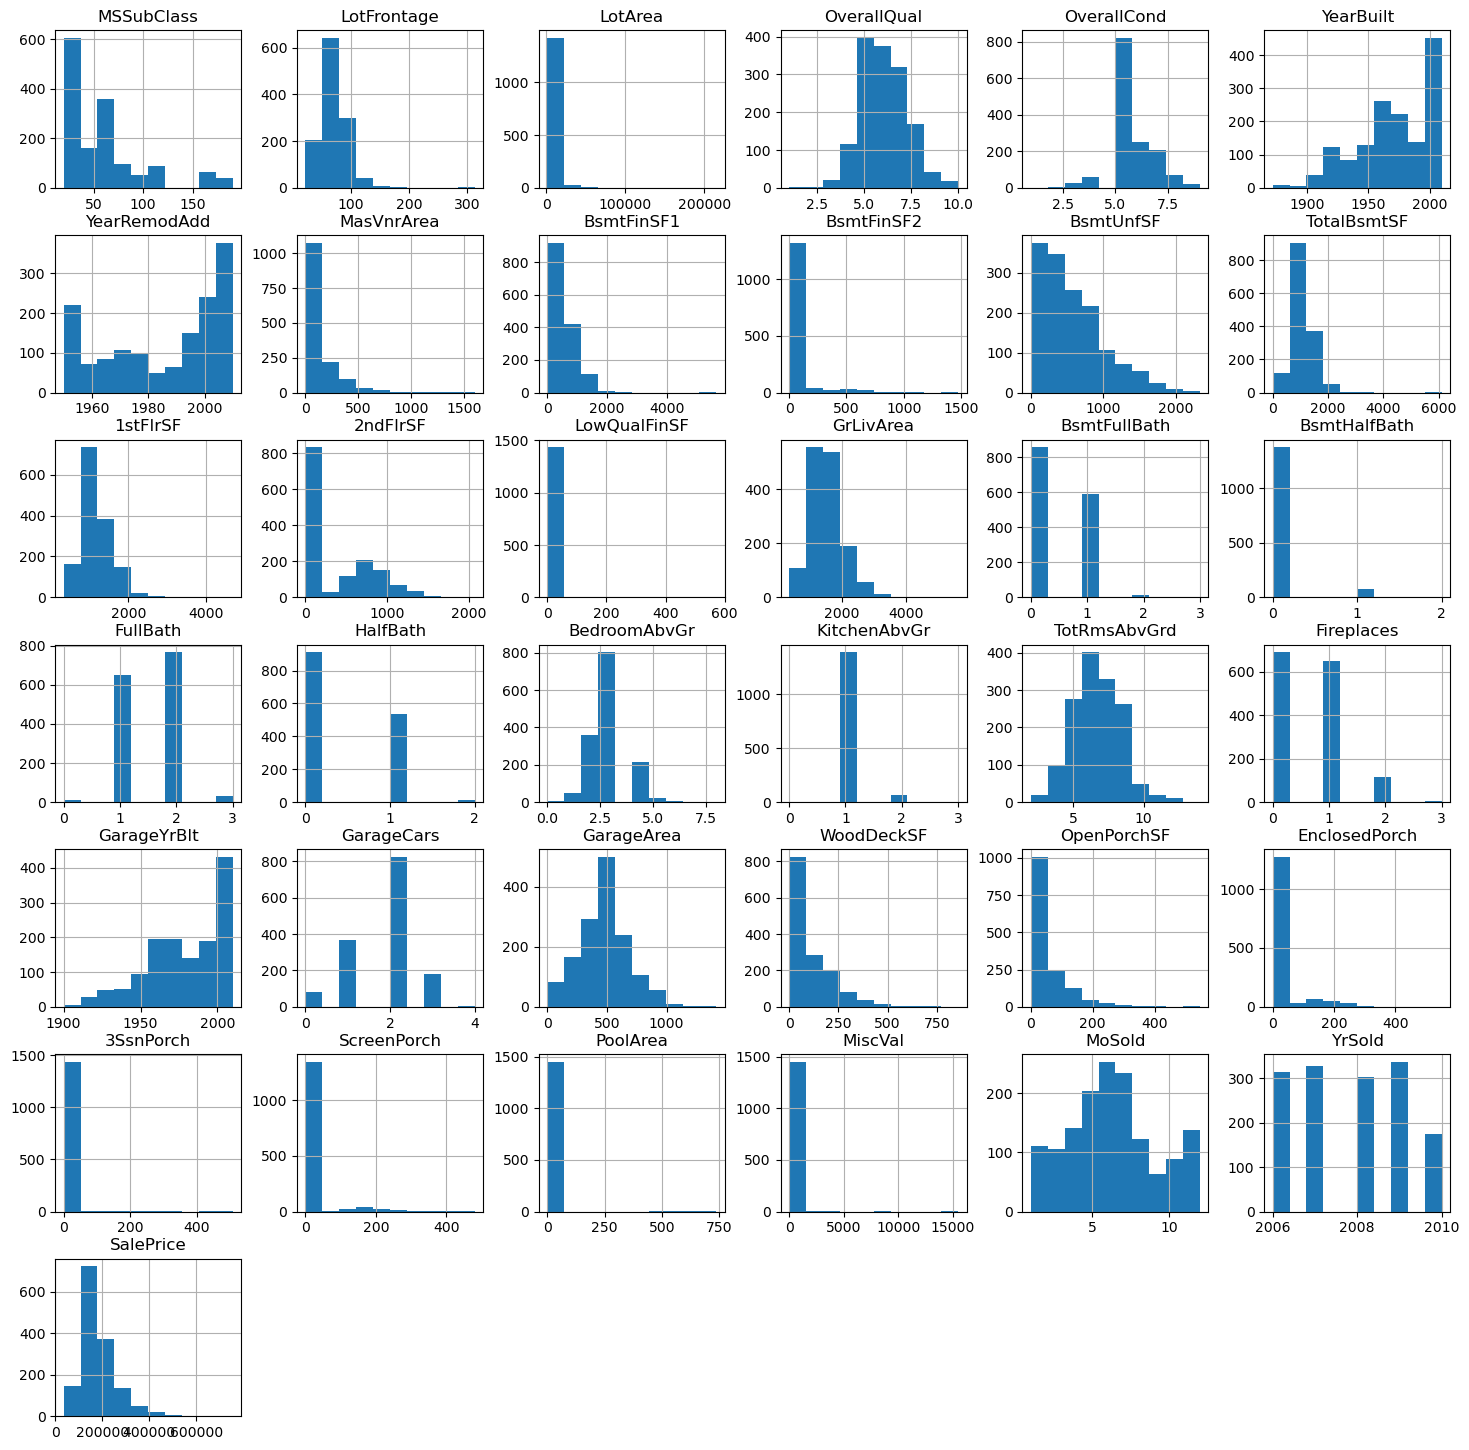

In [11]:
#Checking the distribution of data in numeric columns, are there any outlirers,is it follow normal distribution etc 

df.hist(figsize=(18,18));

In [12]:
# Checking numeric columns correlation (how strongly they effect target column) with target (SalePrice) Column

corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
corr

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

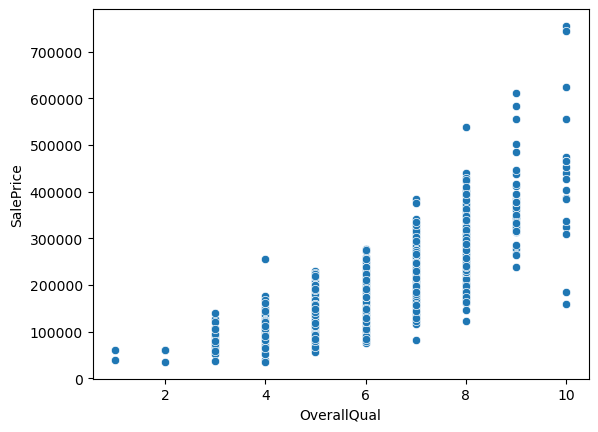

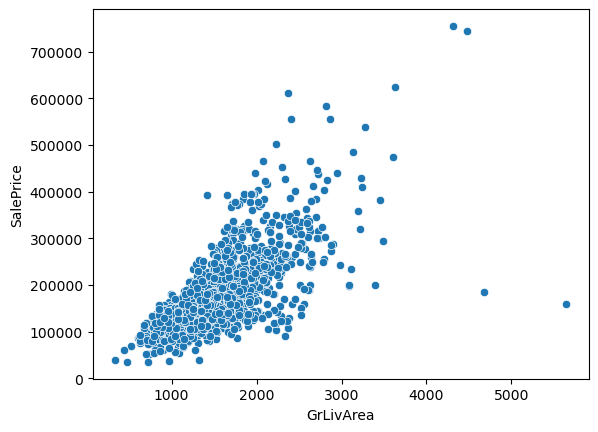

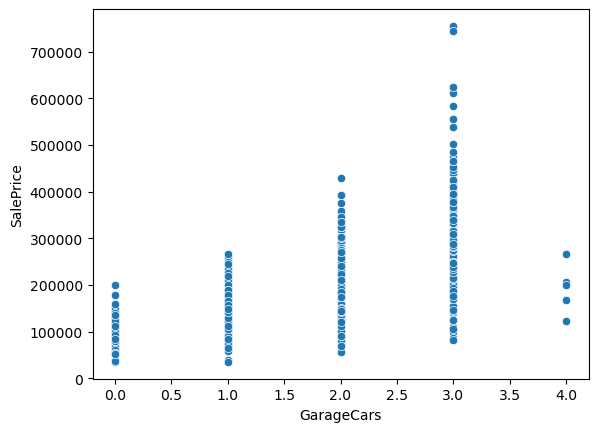

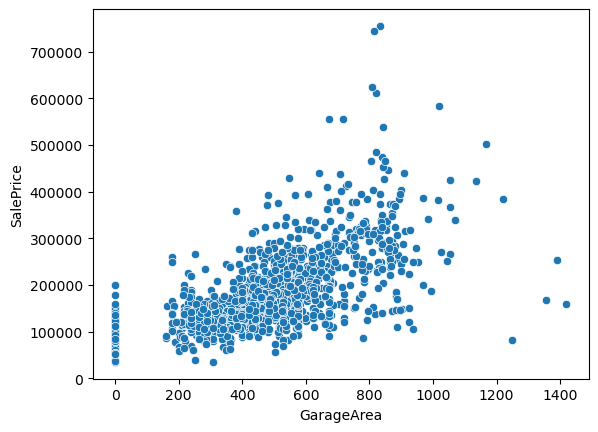

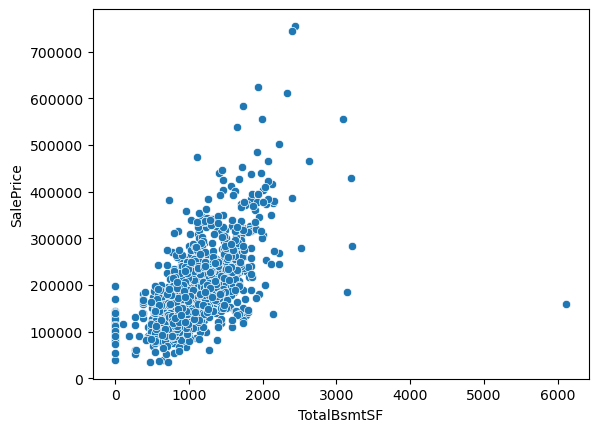

In [13]:
# Checking the correlation of top five elements with target, and which feature helping more or driving the model in
# wrong direction 

top_features = corr.index[1:6]
for col in top_features:
    sns.scatterplot( x=df[col], y=df['SalePrice'])
    plt.show()

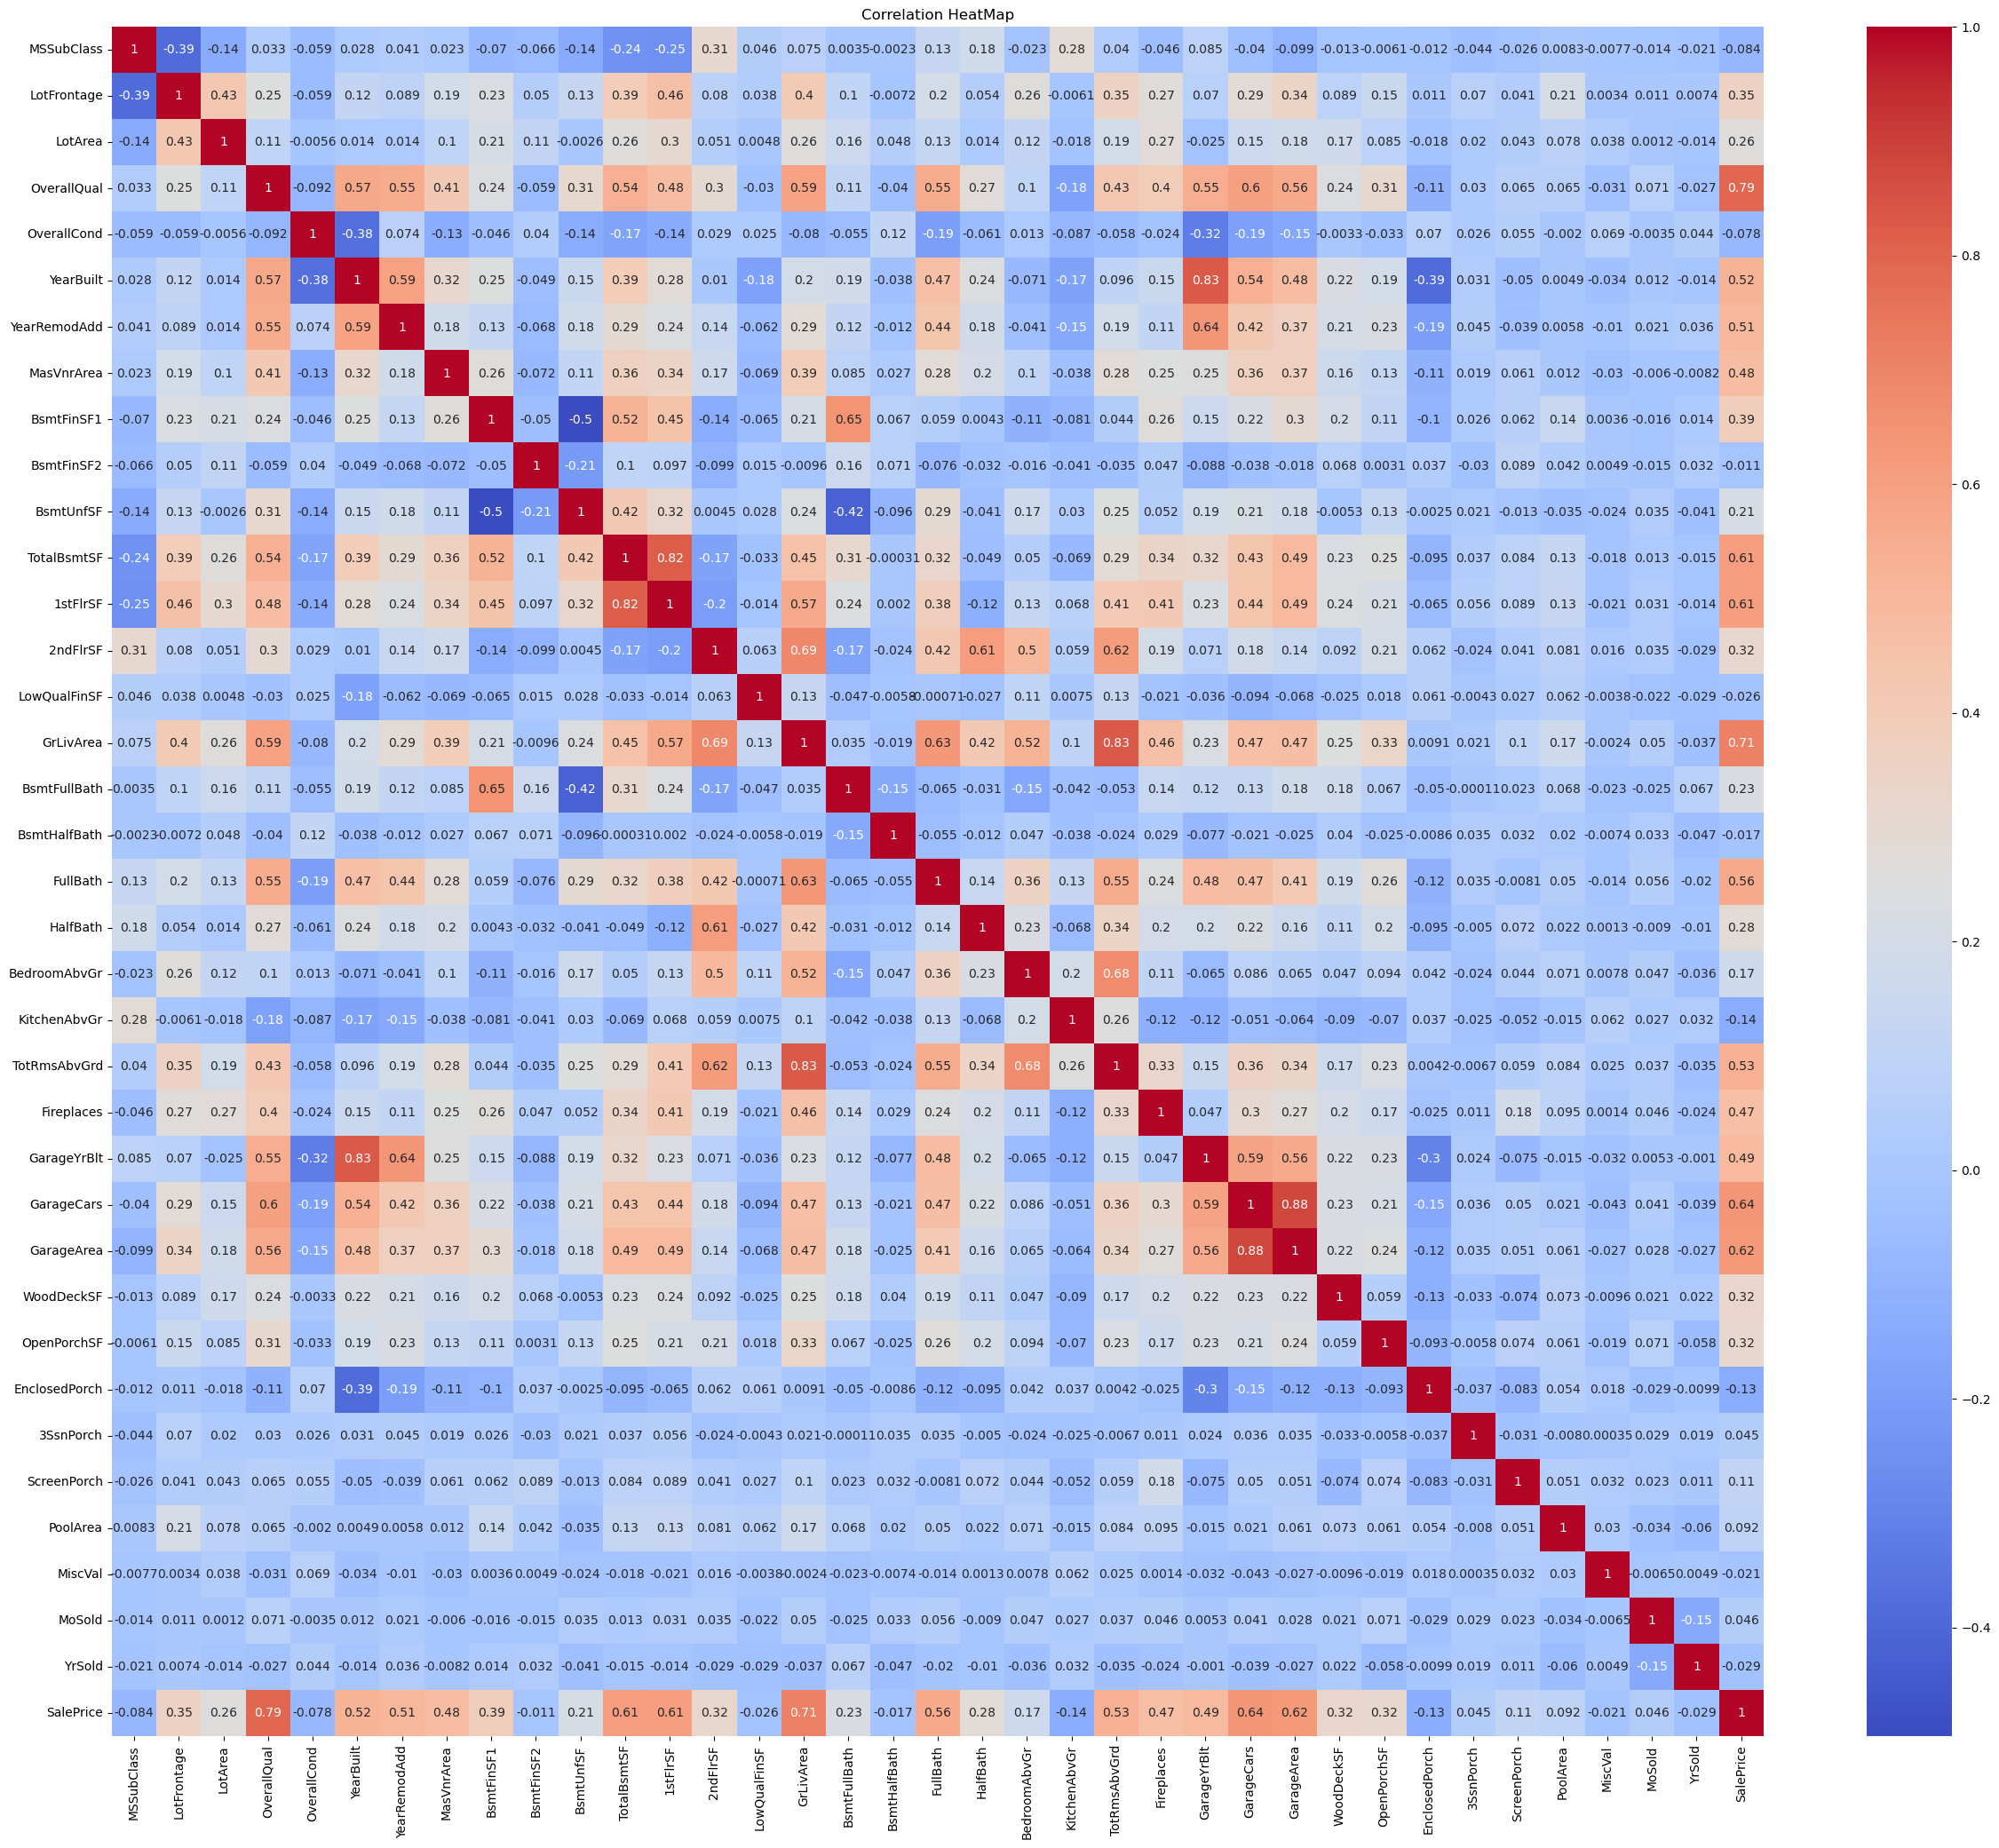

In [14]:
#checking Correlation of different features with each other

plt.figure(figsize=(30,25))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation HeatMap')
plt.show()

In [15]:
X = df.drop('SalePrice', axis=1)  # all input features
y = df['SalePrice']   # target or resultant feature

In [17]:
joblib.dump(X.columns.tolist(), 'columns.pkl')

['columns.pkl']

In [16]:
# Quick view of numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns
# Checking whatever some catagorical columns are not stored as numeric
df[numeric_cols]

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,548,0,61,0,0,0,0,0,2,2008
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,460,298,0,0,0,0,0,0,5,2007
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,608,0,42,0,0,0,0,0,9,2008
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,642,0,35,272,0,0,0,0,2,2006
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,836,192,84,0,0,0,0,0,12,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,460,0,40,0,0,0,0,0,8,2007
1456,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,500,349,0,0,0,0,0,0,2,2010
1457,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,252,0,60,0,0,0,0,2500,5,2010
1458,20,68.0,9717,5,6,1950,1996,0.0,49,1029,...,240,366,0,112,0,0,0,0,4,2010


In [17]:
#We will also drop those categorical column which has high number of unique values
print('Each column has the follwing number of unique values')
for col in categorical_cols:
    print(f'{col} : {df[col].nunique()}')
# There is no feature with high number of unique value, so there is nothing specail to drop

Each column has the follwing number of unique values
MSZoning : 5
Street : 2
LotShape : 4
LandContour : 4
Utilities : 2
LotConfig : 5
LandSlope : 3
Neighborhood : 25
Condition1 : 9
Condition2 : 8
BldgType : 5
HouseStyle : 8
RoofStyle : 6
RoofMatl : 8
Exterior1st : 15
Exterior2nd : 16
ExterQual : 4
ExterCond : 5
Foundation : 6
BsmtQual : 4
BsmtCond : 4
BsmtExposure : 4
BsmtFinType1 : 6
BsmtFinType2 : 6
Heating : 6
HeatingQC : 5
CentralAir : 2
Electrical : 5
KitchenQual : 4
Functional : 7
FireplaceQu : 5
GarageType : 6
GarageFinish : 3
GarageQual : 5
GarageCond : 5
PavedDrive : 3
SaleType : 9
SaleCondition : 6


In [18]:
# Checking whatever some numerical columns are not stored as catagorical
df[categorical_cols]

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,NaN,Attchd,RFn,TA,TA,Y,WD,Normal
1,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
1456,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,...,TA,Min1,TA,Attchd,Unf,TA,TA,Y,WD,Normal
1457,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
1458,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,...,Gd,Typ,NaN,Attchd,Unf,TA,TA,Y,WD,Normal


In [19]:
# Spliting the data into training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

In [20]:
numeric_pipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='mean')),
    #('Scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='most_frequent')),
    ('Encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('Numeric_pipeline', numeric_pipeline, numeric_cols),
    ('Categorical_pipeline', categorical_pipeline, categorical_cols)
], remainder='passthrough')

models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor()
}
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f'R2 Score for {name} is {r2}')
    print(f'mean absolute error for {name} is {mae}')
    print(f'mean squere error for {name} is {mse}')

R2 Score for LinearRegression is 0.8731885814928189
mean absolute error for LinearRegression is 20379.02054197636
mean squere error for LinearRegression is 972684946.7462058
R2 Score for RandomForestRegressor is 0.8862645581981496
mean absolute error for RandomForestRegressor is 17918.676061643837
mean squere error for RandomForestRegressor is 872387939.9387387


In [21]:
pipe_LR = Pipeline([
        ('preprocessing', preprocessor),
        ('model', LinearRegression())])
cvs_LR = cross_val_score(pipe_LR, X, y, cv=5, scoring='r2', n_jobs = -1)

In [22]:
cvs_LR = np.mean(cvs_LR)

In [23]:
pipe_RF = Pipeline([
        ('preprocessing', preprocessor),
        ('model', RandomForestRegressor())])
cvs_RF = cross_val_score(pipe_RF, X, y, cv=5, scoring='r2', n_jobs = -1)

In [24]:
cvs_RF = np.mean(cvs_RF)

In [25]:
#Define hyperparameters using dictionary
params = {
    'model__n_estimators': [10, 100, 200, 300, 500],
    'model__max_depth': [None, 5, 10, 15, 25],
    'model__min_samples_split': [2, 3, 5]
}
search = RandomizedSearchCV(
    pipe_RF,
    params,
    cv=5,
    scoring= 'r2',
    n_jobs = -1,
    verbose = True
)


In [26]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,Pipeline(step...Regressor())])
,param_distributions,"{'model__max_depth': [None, 5, ...], 'model__min_samples_split': [2, 3, ...], 'model__n_estimators': [10, 100, ...]}"
,n_iter,10
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [27]:
y_pred_RSC = search.predict(X_test)
r2_score(y_test, y_pred_RSC)

0.8895582783443835

In [28]:
search.best_params_

{'model__n_estimators': 200,
 'model__min_samples_split': 3,
 'model__max_depth': None}

In [34]:
best_model = search.best_estimator_

In [39]:
y_pred = best_model.predict(X_test)
print(f'R2 score is {r2_score(y_test, y_pred)}')
print(f'Mean Squered Error is {mean_absolute_error(y_test, y_pred):.3f}')
print(f'Mean Squerd Error is {mean_squared_error(y_test, y_pred):.3f}')

R2 score is 0.8895582783443835
Mean Squered Error is 17502.866
Mean Squerd Error is 847124031.982


In [41]:
model = best_model.named_steps['model']
importances = model.feature_importances_

In [45]:
feature_names = best_model.named_steps['preprocessing'].get_feature_names_out()

In [48]:
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
feature_importance.head(10)

,feature,importance
3,Numeric_pipeline__OverallQual,0.558499
15,Numeric_pipeline__GrLivArea,0.121325
11,Numeric_pipeline__TotalBsmtSF,0.031903
13,Numeric_pipeline__2ndFlrSF,0.030565
12,Numeric_pipeline__1stFlrSF,0.029258
8,Numeric_pipeline__BsmtFinSF1,0.026491
26,Numeric_pipeline__GarageArea,0.017767
2,Numeric_pipeline__LotArea,0.014824
25,Numeric_pipeline__GarageCars,0.014401
5,Numeric_pipeline__YearBuilt,0.011469


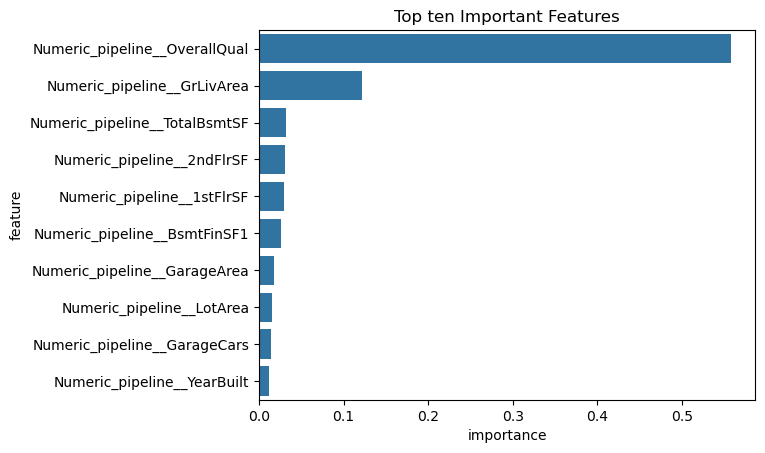

In [57]:
top_features = feature_importance.head(10)
sns.barplot(data=top_features, x='importance', y='feature')
plt.title('Top ten Important Features')
plt.show()

In [58]:

joblib.dump(best_model, 'House_Price_Prediction.pkl')

['House_Price_Prediction.pkl']

In [ ]:
pip install streamlit